In [31]:
import matplotlib
import json
from pathlib import Path
import pandas as pd

In [32]:

def load_results(results_dir):
    results = []
    for path in Path(results_dir).glob("*.json"):
        stem = path.stem
        print(stem)
        args = stem.split("__")
        kwargs = {}

        for i in range(0, len(args), 2):
            kwargs[args[i]] = float(args[i+1])

        with open(results_dir/path, "rb") as f:
            data = json.load(f)
            kwargs.update(data)
        results.append(kwargs)
    return results


In [33]:
vanilla = pd.DataFrame.from_dict(load_results("/root/vllm_prefill/eval/end_to_end/results/vanilla"))
prefill = pd.DataFrame.from_dict(load_results("/root/vllm_prefill/eval/end_to_end/results/prefill_csjf"))
vanilla.sort_values(by="qps", inplace=True)
prefill.sort_values(by="qps", inplace=True)

qps__8__num_users__8__num_documents__20__user_history_mean__20000__user_history_std__2000__user_history_min__10__user_history_max__33000__document_length__150
qps__2__num_users__8__num_documents__20__user_history_mean__20000__user_history_std__2000__user_history_min__10__user_history_max__33000__document_length__150
qps__inf__num_users__8__num_documents__20__user_history_mean__20000__user_history_std__2000__user_history_min__10__user_history_max__33000__document_length__150
qps__4__num_users__8__num_documents__20__user_history_mean__20000__user_history_std__2000__user_history_min__10__user_history_max__33000__document_length__150
qps__8__num_users__8__num_documents__20__user_history_mean__20000__user_history_std__2000__user_history_min__10__user_history_max__33000__document_length__150
qps__2__num_users__8__num_documents__20__user_history_mean__20000__user_history_std__2000__user_history_min__10__user_history_max__33000__document_length__150
qps__inf__num_users__8__num_documents__20__u

In [36]:
prefill["p99_ttft_ms"]

1     8593.393506
3    36919.329774
0    52740.436352
2    62627.270796
Name: p99_ttft_ms, dtype: float64

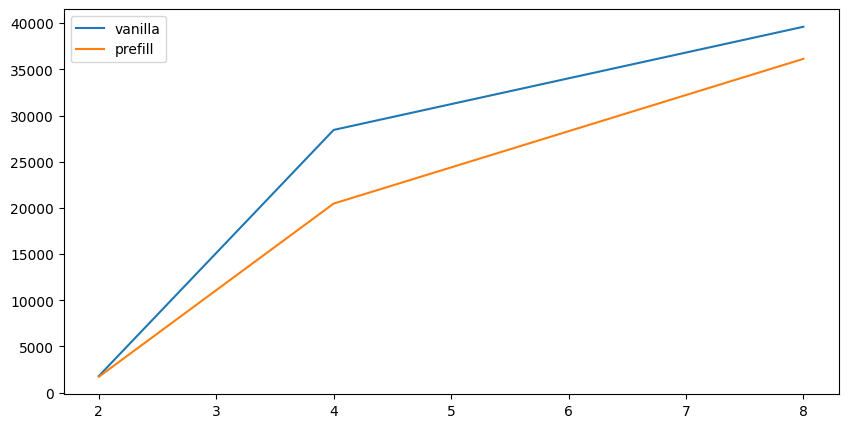

In [27]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(vanilla["qps"], vanilla["median_ttft_ms"], label="vanilla")
ax.plot(prefill["qps"], prefill["median_ttft_ms"], label="prefill")
ax.legend()


